# 01 · Data exploration & cleaning

**Goal:** turn 1,067,371 raw invoice lines into a dataset we can trust for revenue, product and customer analysis.

Each problem below is first *shown* with evidence from the data, then fixed by a rule in `src/cleaning.py`.
The full pipeline (and its audit log) is run at the end.

Data: [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (CC BY 4.0) – all transactions
of a UK-based online gift retailer, 01 Dec 2009 – 09 Dec 2011. Many customers are wholesalers.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True})
BLUE = "#2a78d6"

from src.config import RAW_PARQUET
from src import cleaning as cl

raw = pd.read_parquet(RAW_PARQUET)
print(f"{len(raw):,} rows x {raw.shape[1]} columns")
raw.head()

1,067,371 rows x 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## 1. First look: types and missing values

In [2]:
raw.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  string        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   Int64         
 7   Country      1067371 non-null  str           
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), str(3), string(1)
memory usage: 118.1 MB


In [3]:
raw.isna().sum().to_frame("missing").assign(pct=lambda d: (100 * d.missing / len(raw)).round(1))

,missing,pct
Invoice,0,0.0
StockCode,0,0.0
Description,4382,0.4
Quantity,0,0.0
InvoiceDate,0,0.0
Price,0,0.0
Customer ID,243007,22.8
Country,0,0.0


**Finding:** ~23% of lines have no `Customer ID` (guest checkouts or unrecorded accounts). These are real sales,
so we **keep** them for revenue/product analysis but exclude them from customer analysis (RFM, cohorts).
Missing `Description`s turn out to be almost all zero-price stock adjustments (see section 4).

In [4]:
raw[["Quantity", "Price"]].describe().round(2)

,Quantity,Price
count,1067371.00,1067371.00
mean,9.94,4.65
std,172.71,123.55
min,-80995.00,-53594.36
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
max,80995.00,38970.00


Negative quantities, negative prices and quantities of ±80,995 – clearly not all of this is normal sales.

## 2. Exact duplicate rows

In [5]:
dups = raw[raw.duplicated(keep=False)].sort_values(["Invoice", "StockCode"])
print(f"{raw.duplicated().sum():,} duplicate rows")
dups.head(6)

34,335 duplicate rows


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom


Same invoice, product, minute, quantity and price recorded twice. Keeping them would double-count revenue,
so the dedupe rule keeps only the first copy. (In the pipeline, names are standardised *before* deduplication – two copies of a line can differ only in spelling, e.g. `BUNTING , SPOTTY` vs `SPOTTY BUNTING`.)

## 3. Lines that are not products

In [6]:
non_std = raw[~raw["StockCode"].str.match(r"^\d{5}")]
(non_std.groupby("StockCode")
        .agg(lines=("Invoice", "size"), example=("Description", "first"))
        .sort_values("lines", ascending=False).head(20))

,lines,example
StockCode,,
POST,2122,POSTAGE
DOT,1446,DOTCOM POSTAGE
M,1421,Manual
C2,282,CARRIAGE
D,177,Discount
S,104,SAMPLES
BANK CHARGES,102,Bank Charges
ADJUST,67,Adjustment by john on 26/01/2010 16
AMAZONFEE,43,AMAZON FEE


Postage (`POST`, `DOT`), manual corrections (`M`), Amazon fees, bank charges, bad-debt write-offs (`B`),
test items and gift vouchers are bookkeeping, not merchandise. Codes such as `DCGS0058` are real items from the
"dotcom gift shop" and are kept, and so are codes like `85123A` (5 digits + a letter = a product variant).
The exact list is `NON_PRODUCT_CODES` in `src/config.py` → *Remove non-product lines*.

In [7]:
raw[raw["StockCode"].isin(["B", "AMAZONFEE", "M"])].nsmallest(5, "Price")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,<NA>,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,<NA>,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,<NA>,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,<NA>,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,<NA>,United Kingdom


## 4. Zero / negative prices and stock adjustments

In [8]:
zero = raw[raw["Price"] <= 0]
print(f"{len(zero):,} lines with price <= 0, of which {zero['Customer ID'].isna().mean():.0%} have no customer")
zero["Description"].value_counts(dropna=False).head(12)

6,207 lines with price <= 0, of which 99% have no customer


Description
<NA>                            4382
check                            162
?                                 92
damages                           84
damaged                           81
found                             28
missing                           27
sold as set on dotcom             20
Damaged                           17
adjustment                        16
OWL DOORSTOP                      15
POLYESTER FILLER PAD 45x45cm      12
Name: count, dtype: int64[pyarrow]

These are warehouse movements – "damaged", "lost", "given away", "check", unknown (`NaN`) – not purchases.
One rule drops price ≤ 0, the next drops any remaining non-cancellation line with quantity ≤ 0.

## 5. Cancellations ('C' invoices) and mistaken bulk orders

Invoices starting with `C` are cancellations/returns (negative quantity). We **keep them separately** to measure
return rates. But a few huge orders were cancelled in full minutes later – data-entry mistakes:

In [9]:
big = raw[raw["Quantity"].abs() >= 10_000].sort_values("InvoiceDate")
big[["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "InvoiceDate"]]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,InvoiceDate
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902,2010-02-15 11:57:00
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902,2010-03-17 13:09:00
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,13902,2010-03-17 13:09:00
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902,2010-03-17 13:09:00
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,13902,2010-03-17 13:09:00
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,17940,2010-03-23 15:36:00
135028,502269,21982,PACK OF 12 SUKI TISSUES,10000,0.25,17940,2010-03-23 15:36:00
135029,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,0.25,17940,2010-03-23 15:36:00
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,0.25,17940,2010-03-23 15:36:00
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,0.00,<NA>,2010-05-10 14:55:00


In [10]:
before = raw[raw["Price"] > 0]
after = cl.drop_reversed_bulk_orders(before)
removed = before.loc[before.index.difference(after.index)]
print(f"this rule removes {len(removed)} lines (sale + matching cancellation)")
removed.sort_values(["StockCode", "InvoiceDate"])[["Invoice", "StockCode", "Quantity", "Customer ID"]].head(10)

this rule removes 87 lines (sale + matching cancellation)


,Invoice,StockCode,Quantity,Customer ID
298956,518505,10123G,1104,14277
359656,C524235,10123G,-1104,14277
896637,569214,15034,1200,14533
902909,C569552,15034,-1200,14533
298954,518505,16046,4608,14277
359658,C524235,16046,-4608,14277
298953,518505,16047,5184,14277
359630,C524235,16047,-5184,14277
298952,518505,16053,2000,14277
359659,C524235,16053,-2000,14277


80,995 paper crafts and 74,215 storage jars would otherwise appear as £168k + £77k of "sales" *and* the
same amount of "returns". The *reversed bulk orders* rule removes a sale ≥ 1,000 units together with its exact cancellation
(same customer, product and quantity). Normal-size returns are untouched.

## 6. Inconsistent text

In [11]:
n_names = raw.groupby("StockCode")["Description"].nunique()
print(f"{(n_names > 1).sum():,} stock codes have more than one description, e.g.:")
raw[raw["StockCode"] == n_names.idxmax()]["Description"].value_counts().head()

1,214 stock codes have more than one description, e.g.:


Description
JUMBO BAG OWLS                  1372
missing                            1
wrongly marked. 23343 in box       1
wrongly coded-23343                1
found                              1
Name: count, dtype: int64[pyarrow]

In [12]:
raw["Country"].value_counts().tail(12)

Country
RSA                   169
Bahrain               126
Brazil                 94
Thailand               76
Korea                  63
European Community     61
Lebanon                58
West Indies            54
Bermuda                34
Nigeria                32
Czech Republic         30
Saudi Arabia           10
Name: count, dtype: int64

The *standardise* step (run first in the pipeline) gives each StockCode its most frequent name (upper-case) and renames `EIRE` → Ireland,
`RSA` → South Africa, `USA` → United States.

## 7. Run the full pipeline

In [13]:
sales, returns, log = cl.clean(raw)
log[["step", "rows_before", "rows_removed", "pct_removed", "value_removed_gbp", "rows_after"]]

,step,rows_before,rows_removed,pct_removed,value_removed_gbp,rows_after
0,0. Raw data loaded,1067371,0,0.00,0.00,1067371
1,1. Standardise product names & countries,1067371,0,0.00,0.00,1067371
2,2. Remove exact duplicate rows,1067371,34337,3.22,432268.72,1033034
3,3. Remove non-product lines,1033034,5870,0.57,-71354.97,1027164
4,4. Remove zero / negative prices,1027164,5956,0.58,0.00,1021208
5,5. Remove stock adjustments,1021208,0,0.00,0.00,1021208
6,6. Remove reversed bulk orders,1021208,85,0.01,33244.52,1021123
7,7. Split sales vs returns,1021123,0,0.00,0.00,1021123
8,8. Flag missing Customer ID (kept),1003248,0,0.00,0.00,1003248


In [14]:
for r in log.itertuples():
    print(f"{r.step}: {r.reason}")

0. Raw data loaded: Both Excel sheets (Dec-2009 to Dec-2011) combined.
1. Standardise product names & countries: One name per StockCode (most frequent spelling); EIRE -> Ireland, RSA -> South Africa, etc. Done first so that duplicates differing only in spelling are caught in step 2.
2. Remove exact duplicate rows: Same invoice, product, time, quantity and price recorded twice - would double-count revenue.
3. Remove non-product lines: Postage, Amazon fees, bank charges, manual adjustments, bad-debt write-offs, test items and gift vouchers are not merchandise sales.
4. Remove zero / negative prices: Price <= 0 lines are damaged / lost / given-away stock movements, not customer purchases.
5. Remove stock adjustments: Safety net: a normal invoice (not 'C') with quantity <= 0 is an inventory correction. In this dataset step 4 already catches all of them, so 0 rows is expected.
6. Remove reversed bulk orders: Orders of >= 1,000 units cancelled in full by the same customer (data-entry mistake

## 8. Sanity checks on the result

In [15]:
assert (sales["Quantity"] > 0).all() and (sales["Price"] > 0).all()
assert (returns["Quantity"] < 0).all()
assert not sales.duplicated().any()
assert not sales["StockCode"].isin(["POST", "M", "AMAZONFEE", "B"]).any()
print(f"sales lines: {len(sales):,} | return lines: {len(returns):,}")
print(f"revenue: £{sales['Revenue'].sum():,.0f} | returned: £{-returns['Revenue'].sum():,.0f}")
print(f"date range: {sales['InvoiceDate'].min():%d %b %Y} – {sales['InvoiceDate'].max():%d %b %Y}")

sales lines: 1,003,248 | return lines: 17,875
revenue: £19,327,697 | returned: £434,605
date range: 01 Dec 2009 – 09 Dec 2011


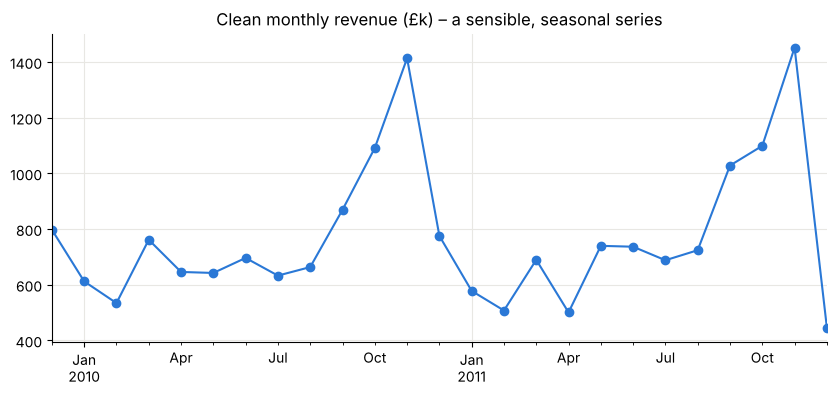

In [16]:
ax = sales.groupby("InvoiceMonth")["Revenue"].sum().div(1e3).plot(color=BLUE, marker="o")
ax.set(title="Clean monthly revenue (£k) – a sensible, seasonal series", xlabel="", ylabel="");

The cleaned files are written by `python -m src.cleaning` to `data/processed/` and used by
`02_analysis.ipynb`, the dashboard and the Excel report.